# AP 155 Lab Exercise
---
## Exercise 5: Matrices

_Instructions_: 
- **Report figure:** Plot of voltage for each node. 
- **Report discussion:**
  - What were the basis linear equations used to set up the matrix in each question of Problem 2?
  - Once you set up the matrices, what function did you use to solve the matrix equation (Could have different answers)? Check the docstring/documentation/other references and summarize the mechanism behind the function 
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Fernandez, Jam
- _Student No._: 2024-05308
- _Section_: THU-WX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

<!-- ### Report figure

<img src="figures/cat.jpg" alt="Alt text" width=45%> <img src="figures/cat.jpg" alt="Alt text" width=45%>


EDIT ME. See instruction above for what to include. Insert caption here, a short description what the figure illustrates. The syntax in markdown for putting a figure is `![Description](local_file_name.png)` or `<img src="/path/to_image.jpg" alt="Alt text" width=45%>`. Make sure the figure has complete elements.
-->

### Report discussion

EDIT ME. See instruction above for what to include. Insert your discussions here. Discuss your key results with at most 150 words per question.

### Other comments
- EDIT ME
- A self reflection can be placed here.
- This portion is not graded.
- You may insert further questions here.


---
## Section 2: Code

### Problem 1: (Newman 6.7) Resistor Ladder

**READ THE INSTRUCTIONS COMPLETELY**

Consider a long chain of resistors wired up like this:

<img src="reschain.png" alt="Alt text" width=95%>

All the resistors have the same resistance $R$.  The power rail at the top is at voltage $V_+=5$V.  The problem is to find the voltages $V_1, \ldots, V_N$ at the internal nodes in the circuit.

1. **Using Ohm's law and the Kirchhoff current law**, which says that the total net current flow out of (or into) any junction in a circuit must be zero, show that the voltages $V_1\ldots V_N$ satisfy the equations

$$3V_1 - V_2 - V_3 = V_+ $$
$$-V_1 + 4V_2 - V_3 - V_4 = V_+ $$
$$\cdots$$
$$-V_{i-2} - V_{i-1} + 4V_i - V_{i+1} - V_{i+2} = 0 $$
$$\cdots$$
$$-V_{N-3} - V_{N-2} + 4V_{N-1} - V_N = V_- = 0 $$
$$-V_{N-2} - V_{N-1} + 3V_N = V_- = 0 $$

Note: The assignment of $V_-$ is to make the equations symmetric

2. Express these equations in vector form $A\vec{v} = \vec{w}$ and find the values of the matrix $A$ and the vector $\vec{w}$.

3. Write a program to solve for the values of the $V_i$ when there are $N=6$ internal junctions with unknown voltages. (Hint: All the values of $V_i$ should lie between zero and $5$V.  If they don't, something is wrong.)

4. Now repeat your calculation for the case where there are $N=10\,000$ internal junctions.  This part is not possible using standard tools like the `np.linalg.solve` function.  You need to make use of the fact that the matrix $\vec{A}$ is banded, and uses `banded.py` by Mark Newman which can be obtained from the link: https://public.websites.umich.edu/~mejn/cp/programs.html

5. Plot your voltages in a histogram, make different histograms for varying number of nodes

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import banded as bd

In [2]:
A = np.array(
    [[3, -1, -1, 0, 0, 0],
    [-1, 4, -1, -1, 0, 0],
    [-1, -1, 4, -1, -1, 0],
    [0, -1, -1, 4, -1, -1],
    [0, 0, -1, -1, 4, -1],
    [0, 0, 0, -1, -1, 3]]
)

print(A)

[[ 3 -1 -1  0  0  0]
 [-1  4 -1 -1  0  0]
 [-1 -1  4 -1 -1  0]
 [ 0 -1 -1  4 -1 -1]
 [ 0  0 -1 -1  4 -1]
 [ 0  0  0 -1 -1  3]]


In [3]:
# 3 
N = 6
V_plus = 5.0

A = np.zeros((N, N))
w = np.zeros(N)

w[0] = V_plus
w[1] = V_plus

for i in range(N):
    if i == 0 or i == N - 1:
        A[i, i] = 3
    else:
        A[i, i] = 4

    if i > 0:
        A[i, i - 1] = -1
    if i < N - 1:
        A[i, i + 1] = -1
        
    if i >= 2:
        A[i, i - 2] = -1
    if i <= N - 3:
        A[i, i + 2] = -1

v = np.linalg.solve(A, w)

print("Matrix:")
print(A)
print("Vector (w):")
print(w)
print("Voltages V:")
print(v)

Matrix:
[[ 3. -1. -1.  0.  0.  0.]
 [-1.  4. -1. -1.  0.  0.]
 [-1. -1.  4. -1. -1.  0.]
 [ 0. -1. -1.  4. -1. -1.]
 [ 0.  0. -1. -1.  4. -1.]
 [ 0.  0.  0. -1. -1.  3.]]
Vector (w):
[5. 5. 0. 0. 0. 0.]
Voltages V:
[3.7254902  3.43137255 2.74509804 2.25490196 1.56862745 1.2745098 ]


In [9]:
# 4 banded
N = 10000
V_plus = 5.0

up = 2
down = 2

A_banded = np.zeros((up + down + 1, N))
w = np.zeros(N)

w[0] = V_plus
w[1] = V_plus

for i in range(N):
    if i == 0 or i == N - 1:
        A_banded[up, i] = 3
    else:
        A_banded[up, i] = 4

    if i > 0:
        A_banded[up + 1, i] = -1
    if i < N - 1:
        A_banded[up - 1, i] = -1
        
    if i >= 2:
        A_banded[up + 2, i] = -1
    if i <= N - 3:
        A_banded[up - 2, i] = -1

v = bd.banded(A_banded, w, up, down)

print("Matrix:")
print(A_banded)
print("Vector (w):")
print(w)
print("Voltages V (first 5):")
print( v[:5])
print("Voltages V (last 5):")
print(v[-5:])

Matrix:
[[-1. -1. -1. ... -1.  0.  0.]
 [-1. -1. -1. ... -1. -1.  0.]
 [ 3.  4.  4. ...  4.  4.  3.]
 [ 0. -1. -1. ... -1. -1. -1.]
 [ 0.  0. -1. ... -1. -1. -1.]]
Vector (w):
[5. 5. 0. ... 0. 0. 0.]
Voltages V (first 5):
[2.34767437 1.47838627 0.56463683 0.34890827 0.43125276]
Voltages V (last 5):
[1.47295236e-04 1.01710611e-04 7.31822667e-05 4.37232195e-05
 3.89684954e-05]


In [5]:
# 4 linalg
N = 10000
V_plus = 5.0

A = np.zeros((N, N))
w = np.zeros(N)

w[0] = V_plus
w[1] = V_plus

for i in range(N):
    if i == 0 or i == N - 1:
        A[i, i] = 3
    else:
        A[i, i] = 4

    if i > 0:
        A[i, i - 1] = -1
    if i < N - 1:
        A[i, i + 1] = -1
        
    if i >= 2:
        A[i, i - 2] = -1
    if i <= N - 3:
        A[i, i + 2] = -1

v = np.linalg.solve(A, w)

print("Matrix:")
print(A)
print("Vector (w):")
print(w)
print("Voltages V:")
print(v)

Matrix:
[[ 3. -1. -1. ...  0.  0.  0.]
 [-1.  4. -1. ...  0.  0.  0.]
 [-1. -1.  4. ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ...  4. -1. -1.]
 [ 0.  0.  0. ... -1.  4. -1.]
 [ 0.  0.  0. ... -1. -1.  3.]]
Vector (w):
[5. 5. 0. ... 0. 0. 0.]
Voltages V:
[4.99888228e+00 4.99861842e+00 4.99802841e+00 ... 1.97158611e-03
 1.38158071e-03 1.11772227e-03]


In [6]:
# 5

def solve_voltages(N):
    V_

#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

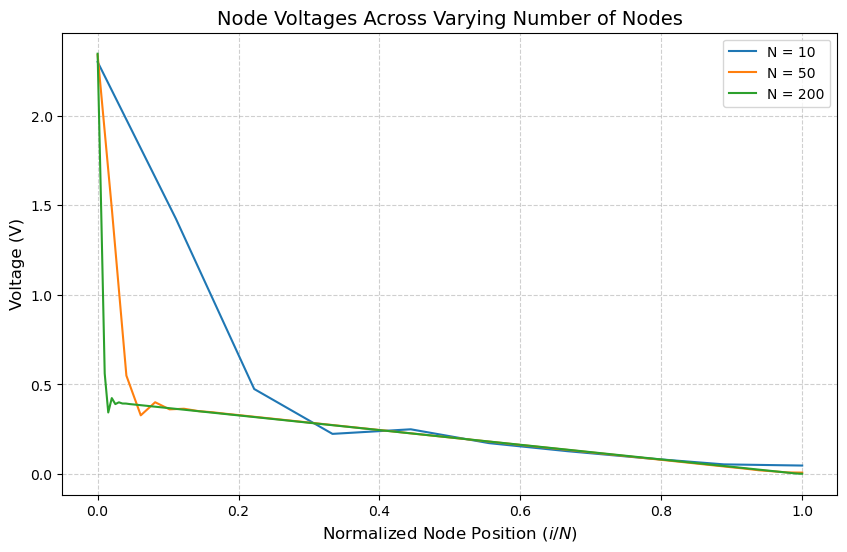

In [7]:
# 5

import numpy as np
import matplotlib.pyplot as plt
import banded as bd

def solve_voltages(N):
    V_plus = 5.0
    up = 2
    down = 2
    
    A_banded = np.zeros((up + down + 1, N))
    w = np.zeros(N)
    
    w[0] = V_plus
    w[1] = V_plus
    
    for i in range(N):
        if i == 0 or i == N - 1:
            A_banded[up, i] = 3
        else:
            A_banded[up, i] = 4

        if i > 0:
            A_banded[up + 1, i] = -1
        if i < N - 1:
            A_banded[up - 1, i] = -1
        if i >= 2:
            A_banded[up + 2, i] = -1
        if i <= N - 3:
            A_banded[up - 2, i] = -1
            
    return bd.banded(A_banded, w, up, down)

# Different node counts to compare
node_counts = [10, 50, 200]

plt.figure(figsize=(10, 6))

for N in node_counts:
    v = solve_voltages(N)
    # Create a normalized position array from 0 to 1 for easy comparison across different N
    x = np.linspace(0, 1, N)
    plt.plot(x, v, label=f'N = {N}', linewidth=1.5)

plt.xlabel('Normalized Node Position ($i / N$)', fontsize=12)
plt.ylabel('Voltage (V)', fontsize=12)
plt.title('Node Voltages Across Varying Number of Nodes', fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)

#### Sample Usage

### Importing functions from a python file

In [8]:
import samplePackage as sP

ModuleNotFoundError: No module named 'samplePackage'

In [ ]:
sP.createZerosArray(4,5)